<a href="https://colab.research.google.com/github/bdashti/v/blob/main/Copy_of_Phase_3_Figures_colab_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Setup Cell
# ----- setup -----
import os, warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

try:
    from google.colab import drive
    if not os.path.isdir('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Plasmids'
except Exception:
    BASE = '.'   # running outside Colab

SAVEPOINT = f'{BASE}/phase2_savepoints/sp_20260612_200020'
# Phase 1 df_test predictions (copy this CSV from your Windows export to Drive once).
# Expected columns: a measured-LFC column and a calibrated-prediction column.
DF_TEST_CSV = f'{BASE}/exports/df_test_predictions.csv'
DF_TEST_PKL = f'{BASE}/sp4_df_test.pkl'   # Phase 1 df_test pickle (copied to Drive)
COLOC_NPZ   = f'{BASE}/streme_outputs/colocalisation_k3_null.npz'

OUTDIR = f'{BASE}/figures' if BASE != '.' else 'figures'
os.makedirs(OUTDIR, exist_ok=True)

plt.rcParams.update({
    'font.size': 10.5, 'axes.titlesize': 11.5, 'axes.labelsize': 10.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.labelsize': 9.5, 'ytick.labelsize': 9.5, 'legend.fontsize': 9,
    'figure.dpi': 110, 'savefig.facecolor': 'white', 'axes.grid': False,
})
COL = {'comp': '#C24646', 'alt': '#9AA0A6', 'stable': '#2E7DB1',
       'hi': '#E0922F', 'ceil': '#5A5A5A', 'pos': '#2E7DB1', 'neg': '#C24646'}

def save_fig(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(f'{OUTDIR}/{name}.{ext}', dpi=600, bbox_inches='tight')
    print('saved', f'{OUTDIR}/{name}.png')

def panel_letter(ax, s):
    ax.text(-0.1, 1.06, s, transform=ax.transAxes, fontsize=13, fontweight='bold',
            va='top', ha='right')

def load_globals():
    try:
        import joblib
        g = joblib.load(f'{SAVEPOINT}/globals.joblib')
        return g if isinstance(g, dict) else {}
    except Exception as e:
        print('  [globals not loaded:', e, ']'); return {}

print('setup ok; OUTDIR =', OUTDIR)


setup ok; OUTDIR = /content/drive/MyDrive/Plasmids/figures


saved /content/drive/MyDrive/Plasmids/figures/Fig2_supervised_performance.png


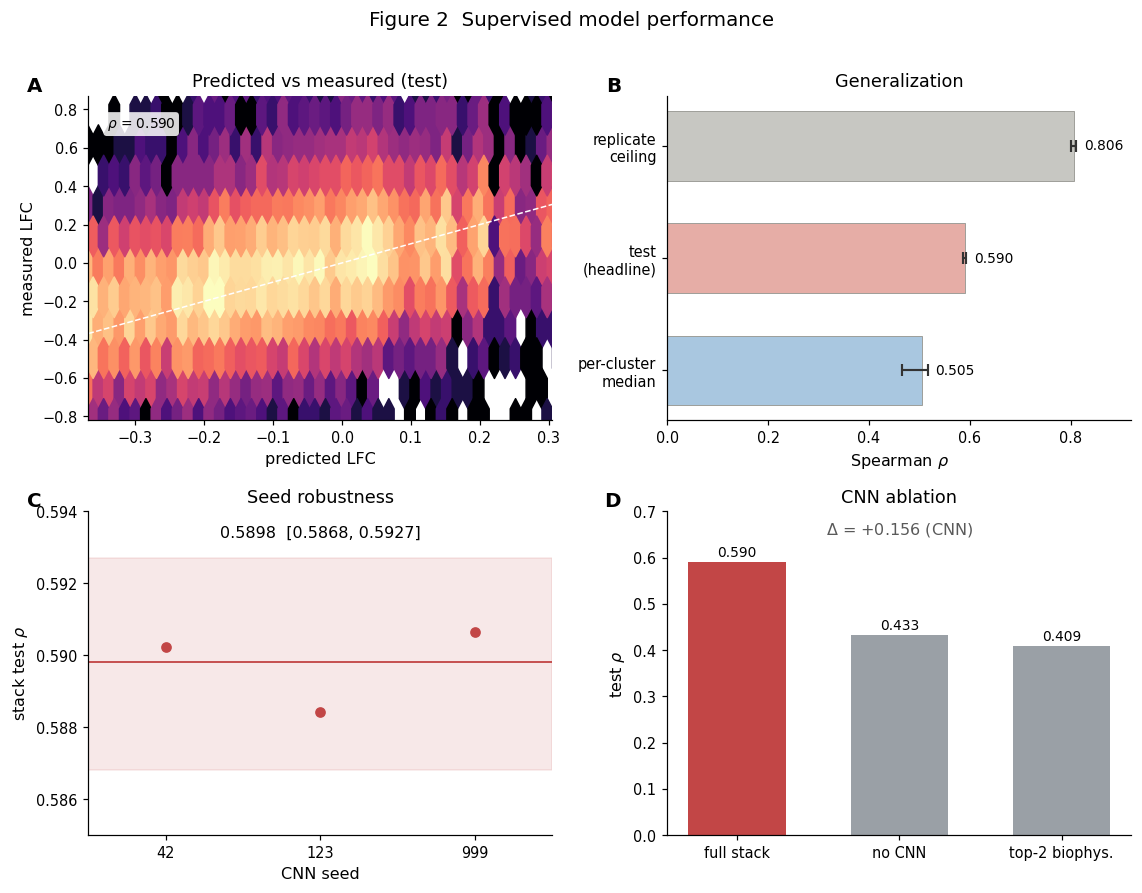

In [ ]:
#@title Figure 2 — supervised performance
fig, ax = plt.subplots(2, 2, figsize=(10.5, 8))

# 2A predicted vs measured.
DF_TEST_PKL = f'{BASE}/sp4_df_test.pkl'
a = ax[0, 0]
def _find(cols, subs):
    for c in cols:
        if any(s in c.lower() for s in subs):
            return c
    return None
try:
    import pandas as pd
    _g = globals().get('df_test', None)
    d = _g if (_g is not None and hasattr(_g, 'columns')) else pd.read_pickle(DF_TEST_PKL)
    meas = _find(d.columns, ['log2fc', 'lfc', 'measured'])
    pred = _find(d.columns, ['stack_pred_calib', 'pred_calib', 'pred'])
    md, pr = d[meas].to_numpy(float), d[pred].to_numpy(float)
    ok = np.isfinite(md) & np.isfinite(pr)
    a.hexbin(pr[ok], md[ok], gridsize=45, mincnt=1, cmap='magma', bins='log')
    xlo, xhi = np.percentile(pr[ok], [1, 99])
    a.plot([xlo, xhi], [xlo, xhi], color='w', lw=1, ls='--')
    a.set_xlim(xlo, xhi); a.set_ylim(*np.percentile(md[ok], [1, 99]))
    a.set_xlabel('predicted LFC'); a.set_ylabel('measured LFC')
    a.text(0.04, 0.94, r'$\rho$ = 0.590', transform=a.transAxes, color='k', fontsize=9, va='top',
           bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85))
except Exception as e:
    a.text(0.5, 0.5, f'df_test not found\n({DF_TEST_PKL})',
           ha='center', va='center', transform=a.transAxes, color=COL['alt'], fontsize=9)
    a.set_xticks([]); a.set_yticks([])
a.set_title('Predicted vs measured (test)')
panel_letter(a, 'A')

# 2B generalization (horizontal bar chart, pale bars so CI whiskers read clearly)
b = ax[0, 1]
labels = ['replicate\nceiling', 'test\n(headline)', 'per-cluster\nmedian']
vals = [0.8062, 0.5898, 0.5046]
lo = [0.8012, 0.5868, 0.4652]; hi = [0.8110, 0.5927, 0.5168]
err = [[v - l for v, l in zip(vals, lo)], [h - v for v, h in zip(vals, hi)]]
pale = ['#C7C7C2', '#E6ADA6', '#A9C7E0']   # pale grey / coral / blue
y = np.arange(len(labels))
b.barh(y, vals, xerr=err, height=0.62, color=pale, edgecolor='#9A9A95', linewidth=0.6,
       capsize=4, error_kw=dict(ecolor='#333333', lw=1.4, capthick=1.4))
for i, v in enumerate(vals):
    b.text(v + err[1][i] + 0.015, i, f'{v:.3f}', va='center', fontsize=9)
b.set_yticks(y); b.set_yticklabels(labels); b.invert_yaxis()
b.set_xlim(0, 0.92); b.set_xlabel(r'Spearman $\rho$')
b.set_title('Generalization'); panel_letter(b, 'B')

# 2C 3-seed CI
c = ax[1, 0]
seeds = [0.590217, 0.588417, 0.590639]
mean, clo, chi = 0.5898, 0.5868, 0.5927
c.axhspan(clo, chi, color=COL['comp'], alpha=0.12)
c.axhline(mean, color=COL['comp'], lw=1.2)
xpos = np.arange(len(seeds))
c.scatter(xpos, seeds, color=COL['comp'], zorder=3, s=36)
c.set_xticks(xpos); c.set_xticklabels(['42', '123', '999']); c.set_xlabel('CNN seed')
c.set_xlim(-0.5, 2.5)
c.set_ylabel(r'stack test $\rho$'); c.set_ylim(0.585, 0.594)
c.text(0.5, 0.92, '0.5898  [0.5868, 0.5927]', transform=c.transAxes, ha='center')
c.set_title('Seed robustness'); panel_letter(c, 'C')

# 2D CNN ablation (no connector line)
d2 = ax[1, 1]
albl = ['full stack', 'no CNN', 'top-2 biophys.']
av = [0.5895, 0.4331, 0.4093]
bars = d2.bar(albl, av, color=[COL['comp'], COL['alt'], COL['alt']], width=0.6)
d2.set_ylabel(r'test $\rho$'); d2.set_ylim(0, 0.7)
for r, v in zip(bars, av):
    d2.text(r.get_x() + r.get_width() / 2, v + 0.012, f'{v:.3f}', ha='center', fontsize=9)
d2.text(0.5, 0.93, r'$\Delta$ = +0.156 (CNN)', transform=d2.transAxes, ha='center', color=COL['ceil'])
d2.set_title('CNN ablation'); panel_letter(d2, 'D')

fig.suptitle('Figure 2  Supervised model performance', y=1.01, fontsize=13)
fig.tight_layout()
save_fig(fig, 'Fig2_supervised_performance')

saved /content/drive/MyDrive/Plasmids/figures/Fig3_composition.png


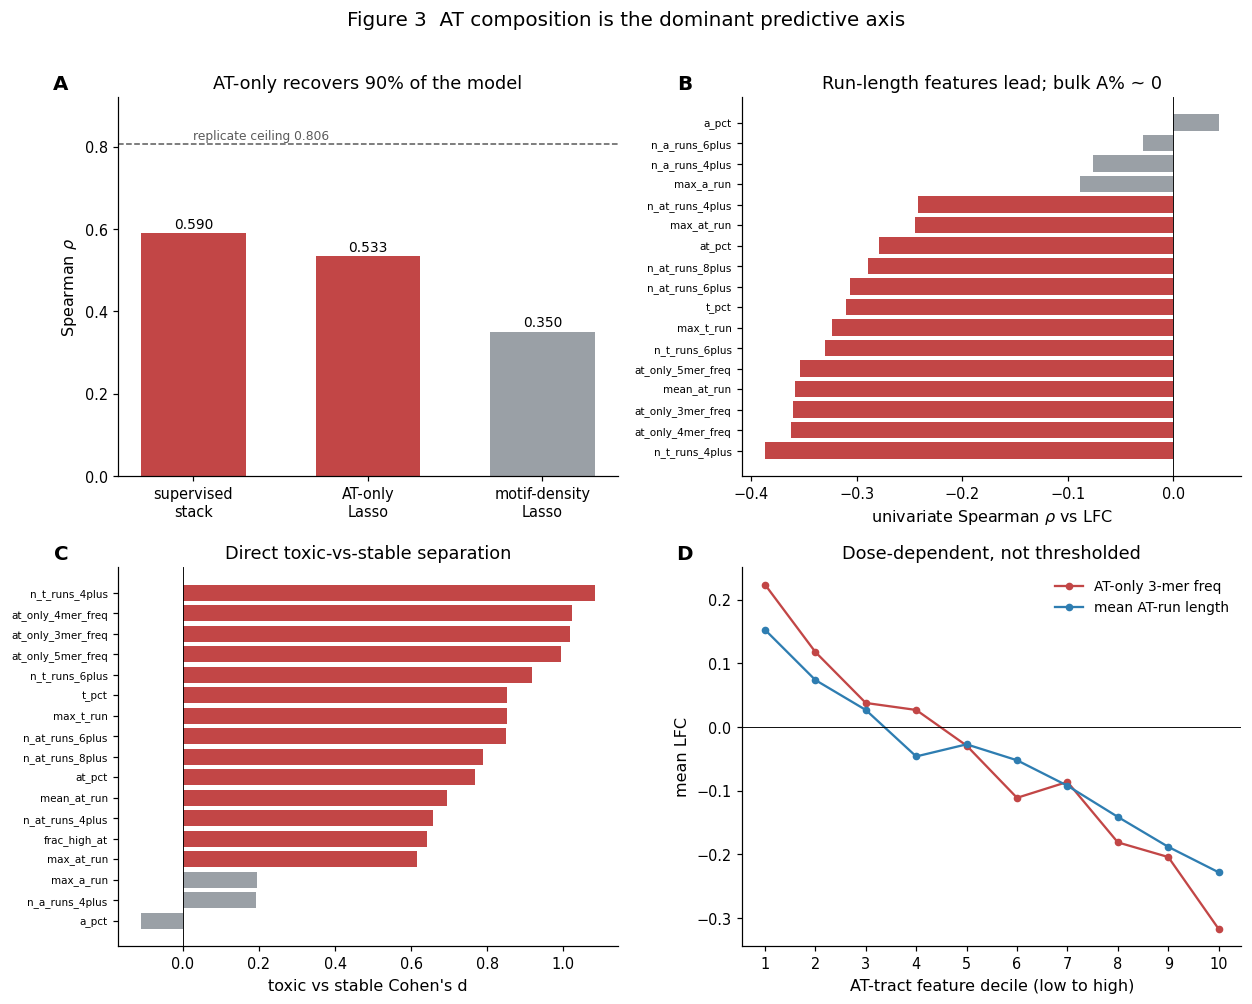

In [ ]:
#@title Figure 3 — composition is the predictive axis
fig, ax = plt.subplots(2, 2, figsize=(11.5, 9))

# 3A model comparison
a = ax[0, 0]
models = ['supervised\nstack', 'AT-only\nLasso', 'motif-density\nLasso']
vals = [0.5895, 0.5331, 0.3501]
a.bar(models, vals, color=[COL['comp'], COL['comp'], COL['alt']], width=0.6)
a.axhline(0.8062, color=COL['ceil'], ls='--', lw=1)
a.text(0.0, 0.8062 + 0.012, 'replicate ceiling 0.806', ha='left', fontsize=8, color=COL['ceil'])
for i, v in enumerate(vals):
    a.text(i, v + 0.012, f'{v:.3f}', ha='center', fontsize=9)
a.set_ylim(0, 0.92); a.set_ylabel(r'Spearman $\rho$')
a.set_title('AT-only recovers 90% of the model'); panel_letter(a, 'A')

# 3B AT-feature univariate ranking (Cell 25)
b = ax[0, 1]
feats = [('n_t_runs_4plus', -0.387), ('at_only_4mer_freq', -0.362), ('at_only_3mer_freq', -0.360),
         ('mean_at_run', -0.359), ('at_only_5mer_freq', -0.354), ('n_t_runs_6plus', -0.330),
         ('max_t_run', -0.323), ('t_pct', -0.310), ('n_at_runs_6plus', -0.306),
         ('n_at_runs_8plus', -0.289), ('at_pct', -0.279), ('max_at_run', -0.245),
         ('n_at_runs_4plus', -0.242), ('max_a_run', -0.088), ('n_a_runs_4plus', -0.076),
         ('a_pct', 0.043), ('n_a_runs_6plus', -0.029)]
feats = sorted(feats, key=lambda x: x[1])
names = [f[0] for f in feats]; vals = [f[1] for f in feats]
cols = [COL['comp'] if abs(v) >= 0.20 else COL['alt'] for v in vals]
b.barh(range(len(names)), vals, color=cols)
b.set_yticks(range(len(names))); b.set_yticklabels(names, fontsize=6.8)
b.axvline(0, color='k', lw=0.6); b.set_xlabel(r'univariate Spearman $\rho$ vs LFC')
b.set_title('Run-length features lead; bulk A% ~ 0'); panel_letter(b, 'B')

# 3C direct toxic-vs-stable separation (Cell 27a)
c = ax[1, 0]
d27 = [('n_t_runs_4plus', 1.083), ('at_only_4mer_freq', 1.024), ('at_only_3mer_freq', 1.018),
       ('at_only_5mer_freq', 0.993), ('n_t_runs_6plus', 0.918), ('t_pct', 0.853),
       ('max_t_run', 0.851), ('n_at_runs_6plus', 0.850), ('n_at_runs_8plus', 0.788),
       ('at_pct', 0.767), ('mean_at_run', 0.694), ('n_at_runs_4plus', 0.658),
       ('frac_high_at', 0.641), ('max_at_run', 0.615), ('max_a_run', 0.194),
       ('n_a_runs_4plus', 0.192), ('a_pct', -0.110)]
d27 = sorted(d27, key=lambda x: x[1])
names = [x[0] for x in d27]; vals = [x[1] for x in d27]
cols = [COL['comp'] if v >= 0.5 else COL['alt'] for v in vals]
c.barh(range(len(names)), vals, color=cols)
c.set_yticks(range(len(names))); c.set_yticklabels(names, fontsize=6.8)
c.axvline(0, color='k', lw=0.6); c.set_xlabel(r"toxic vs stable Cohen's d")
c.set_title('Direct toxic-vs-stable separation'); panel_letter(c, 'C')

# 3D dose-response (Cell 27b)
d = ax[1, 1]
x = list(range(1, 11))
y1 = [0.224, 0.118, 0.038, 0.027, -0.029, -0.111, -0.086, -0.181, -0.204, -0.317]
y2 = [0.153, 0.074, 0.027, -0.046, -0.027, -0.052, -0.092, -0.141, -0.188, -0.228]
d.plot(x, y1, '-o', color=COL['comp'], ms=4, label='AT-only 3-mer freq')
d.plot(x, y2, '-o', color=COL['stable'], ms=4, label='mean AT-run length')
d.axhline(0, color='k', lw=0.6)
d.set_xlabel('AT-tract feature decile (low to high)'); d.set_ylabel('mean LFC')
d.set_xticks(x); d.legend(frameon=False, loc='upper right')
d.set_title('Dose-dependent, not thresholded'); panel_letter(d, 'D')

fig.suptitle('Figure 3  AT composition is the dominant predictive axis', y=1.01, fontsize=13)
fig.tight_layout()
save_fig(fig, 'Fig3_composition')


saved /content/drive/MyDrive/Plasmids/figures/Fig4_unsupervised_motifs.png


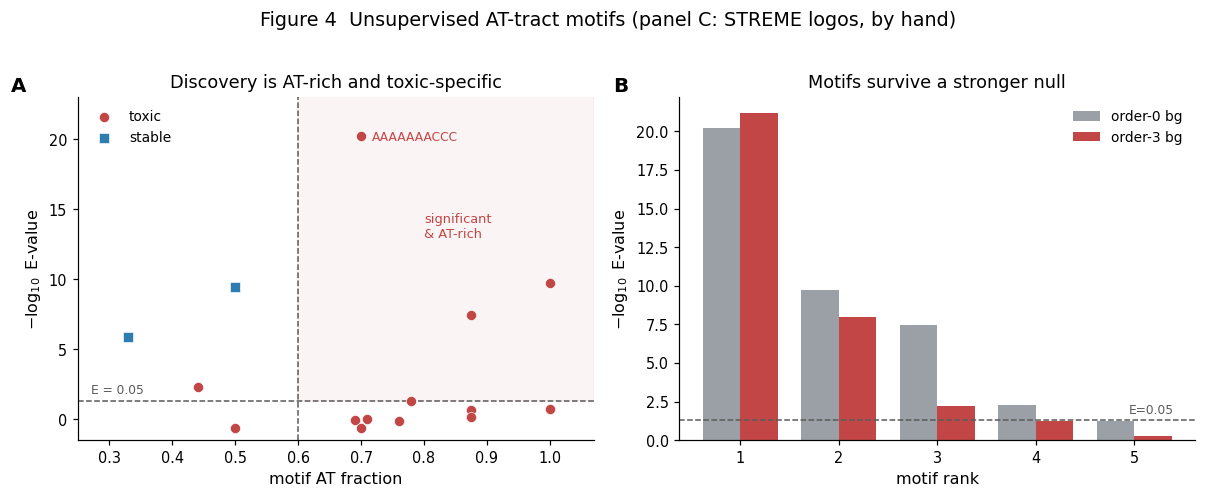

In [ ]:
#@title Figure 4 — unsupervised motifs (logos by hand)
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))

# 4A discovered-motif landscape: AT content vs significance, toxic vs stable
a = ax[0]
# primary discovery (order-0): (consensus AT fraction, E-value)
toxic = [(0.70, 6e-21, 'AAAAAAACCC'), (1.00, 1.8e-10, ''), (0.875, 3.6e-8, ''),
         (0.44, 5.2e-3, ''), (0.78, 5.3e-2, ''), (1.00, 1.8e-1, ''),
         (0.875, 2.3e-1, ''), (0.875, 7.4e-1, ''), (0.71, 1.0, ''),
         (0.69, 1.1, ''), (0.76, 1.4, ''), (0.50, 4.3, ''), (0.70, 4.3, '')]
stable = [(0.50, 3.4e-10), (0.33, 1.3e-6)]   # incl. order-3 stable motif
sig = -np.log10(0.05)
a.add_patch(Rectangle((0.6, sig), 0.47, 24, color=COL['comp'], alpha=0.06, zorder=0))
a.axhline(sig, ls='--', color=COL['ceil'], lw=1)
a.axvline(0.6, ls='--', color=COL['ceil'], lw=1)
tx = [p[0] for p in toxic]; ty = [-np.log10(p[1]) for p in toxic]
sx = [p[0] for p in stable]; sy = [-np.log10(p[1]) for p in stable]
a.scatter(tx, ty, s=44, color=COL['comp'], edgecolor='white', lw=0.4, label='toxic', zorder=3)
a.scatter(sx, sy, s=48, marker='s', color=COL['stable'], edgecolor='white', lw=0.4, label='stable', zorder=3)
a.annotate('AAAAAAACCC', (0.70, -np.log10(6e-21)), textcoords='offset points',
           xytext=(7, -3), fontsize=8, color=COL['comp'])
a.text(0.80, 13, 'significant\n& AT-rich', fontsize=8.5, color=COL['comp'])
a.text(0.27, sig + 0.5, 'E = 0.05', fontsize=8, color=COL['ceil'])
a.set_xlim(0.25, 1.07); a.set_ylim(-1.5, 23)
a.set_xlabel('motif AT fraction'); a.set_ylabel(r'$-\log_{10}$ E-value')
a.legend(frameon=False, loc='upper left')
a.set_title('Discovery is AT-rich and toxic-specific'); panel_letter(a, 'A')

# 4B order-0 vs order-3 survival (strong-null diagnostic)
b = ax[1]
o0 = [6e-21, 1.8e-10, 3.6e-8, 5.2e-3, 5.3e-2]
o3 = [6.8e-22, 9.7e-9, 5.9e-3, 5.9e-2, 5.6e-1]
idx = np.arange(1, 6); w = 0.38
b.bar(idx - w/2, [-np.log10(v) for v in o0], w, label='order-0 bg', color=COL['alt'])
b.bar(idx + w/2, [-np.log10(v) for v in o3], w, label='order-3 bg', color=COL['comp'])
b.axhline(-np.log10(0.05), color=COL['ceil'], ls='--', lw=1)
b.text(5.4, -np.log10(0.05) + 0.4, 'E=0.05', ha='right', fontsize=8, color=COL['ceil'])
b.set_xlabel('motif rank'); b.set_ylabel(r'$-\log_{10}$ E-value')
b.legend(frameon=False); b.set_title('Motifs survive a stronger null'); panel_letter(b, 'B')

fig.suptitle('Figure 4  Unsupervised AT-tract motifs (panel C: STREME logos, by hand)',
             y=1.02, fontsize=12.5)
fig.tight_layout()
save_fig(fig, 'Fig4_unsupervised_motifs')


saved /content/drive/MyDrive/Plasmids/figures/Fig5_convergence_and_null.png


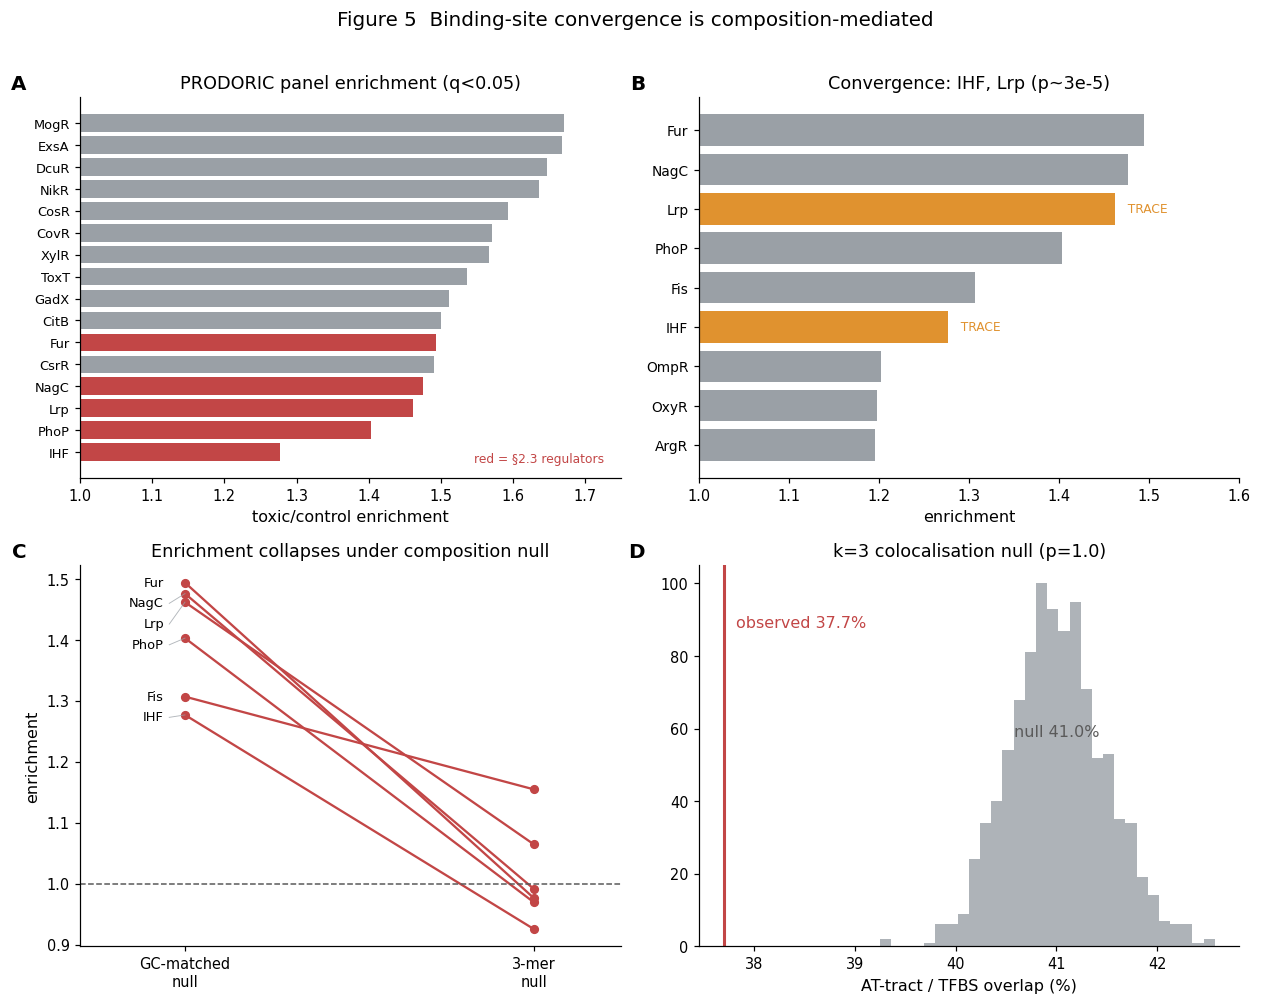

In [ ]:
#@title Figure 5 — TF convergence and composition null
fig, ax = plt.subplots(2, 2, figsize=(11.5, 9))

# 5A PRODORIC top enrichment
a = ax[0, 0]
top = [('MogR', 1.671), ('ExsA', 1.668), ('DcuR', 1.648), ('NikR', 1.636),
       ('CosR', 1.594), ('CovR', 1.572), ('XylR', 1.567), ('ToxT', 1.536),
       ('GadX', 1.511), ('CitB', 1.500), ('Fur', 1.494), ('CsrR', 1.491),
       ('NagC', 1.476), ('Lrp', 1.462), ('IHF', 1.277), ('PhoP', 1.403)]
key = {'Fur', 'Lrp', 'IHF', 'PhoP', 'Fis', 'OmpR', 'OxyR', 'ArgR', 'NagC', 'CRP', 'NarL'}
top = sorted(top, key=lambda x: x[1])
names = [t[0] for t in top]; vals = [t[1] for t in top]
cols = [COL['comp'] if n in key else COL['alt'] for n in names]
a.barh(range(len(names)), vals, color=cols)
a.set_yticks(range(len(names))); a.set_yticklabels(names, fontsize=8.5)
a.set_xlim(1.0, 1.75); a.set_xlabel('toxic/control enrichment')
a.text(0.97, 0.04, 'red = §2.3 regulators', transform=a.transAxes, fontsize=8,
       ha='right', color=COL['comp'])
a.set_title('PRODORIC panel enrichment (q<0.05)'); panel_letter(a, 'A')

# 5B TRACE convergence
b = ax[0, 1]
conv = [('ArgR', 1.195, False), ('OxyR', 1.198, False), ('OmpR', 1.202, False),
        ('IHF', 1.277, True), ('Fis', 1.307, False), ('PhoP', 1.403, False),
        ('Lrp', 1.462, True), ('NagC', 1.476, False), ('Fur', 1.494, False)]
names = [c[0] for c in conv]; vals = [c[1] for c in conv]
cols = [COL['hi'] if c[2] else COL['alt'] for c in conv]
b.barh(range(len(names)), vals, color=cols)
for i, c in enumerate(conv):
    if c[2]:
        b.text(c[1]+0.005, i, '  TRACE', va='center', fontsize=8, color=COL['hi'])
b.set_yticks(range(len(names))); b.set_yticklabels(names, fontsize=9)
b.set_xlim(1.0, 1.6); b.set_xlabel('enrichment')
b.set_title('Convergence: IHF, Lrp (p~3e-5)'); panel_letter(b, 'B')

# 5C GC null vs 3-mer null collapse  (labels decluttered with leaders)
c = ax[1, 0]
pairs = [('Lrp', 1.462, 1.065), ('IHF', 1.277, 0.926), ('PhoP', 1.403, 0.970),
         ('Fur', 1.494, 0.977), ('NagC', 1.476, 0.992), ('Fis', 1.307, 1.155)]
for tf, gc, k3 in pairs:
    c.plot([0, 1], [gc, k3], '-o', color=COL['comp'], ms=5)
lab = sorted(pairs, key=lambda p: -p[1]); min_gap = 0.034; prev = None; ypos = {}
for tf, gc, k3 in lab:
    y = gc if prev is None else min(gc, prev - min_gap); ypos[tf] = y; prev = y
for tf, gc, k3 in pairs:
    if abs(ypos[tf] - gc) > 0.004:
        c.plot([-0.045, 0], [ypos[tf], gc], color=COL['alt'], lw=0.6, alpha=0.75)
    c.text(-0.06, ypos[tf], tf, ha='right', va='center', fontsize=8.5)
c.axhline(1.0, color=COL['ceil'], ls='--', lw=1)
c.set_xticks([0, 1]); c.set_xticklabels(['GC-matched\nnull', '3-mer\nnull'])
c.set_xlim(-0.30, 1.25); c.set_ylabel('enrichment')
c.set_title('Enrichment collapses under composition null'); panel_letter(c, 'C')

# 5D colocalisation null (observed label to the right of the line)
d = ax[1, 1]
obs = 37.7
try:
    z = np.load(COLOC_NPZ)
    arr = z[z.files[0]]
    arr = arr[np.isfinite(arr)]
    d.hist(arr, bins=30, color=COL['alt'], alpha=0.8)
except Exception:
    xs = np.linspace(38.5, 43.5, 400)
    g = np.exp(-0.5*((xs-41.0)/0.49)**2)
    d.fill_between(xs, g*120, color=COL['alt'], alpha=0.8)
    d.set_yticks([])
d.axvline(obs, color=COL['comp'], lw=2)
d.text(obs+0.12, d.get_ylim()[1]*0.85, 'observed 37.7%', ha='left', va='center', color=COL['comp'])
d.text(41.0, d.get_ylim()[1]*0.55, 'null 41.0%', ha='center', color=COL['ceil'])
d.set_xlabel('AT-tract / TFBS overlap (%)')
d.set_title('k=3 colocalisation null (p=1.0)'); panel_letter(d, 'D')

fig.suptitle('Figure 5  Binding-site convergence is composition-mediated', y=1.01, fontsize=13)
fig.tight_layout()
save_fig(fig, 'Fig5_convergence_and_null')

saved /content/drive/MyDrive/Plasmids/figures/Fig6_single_axis.png


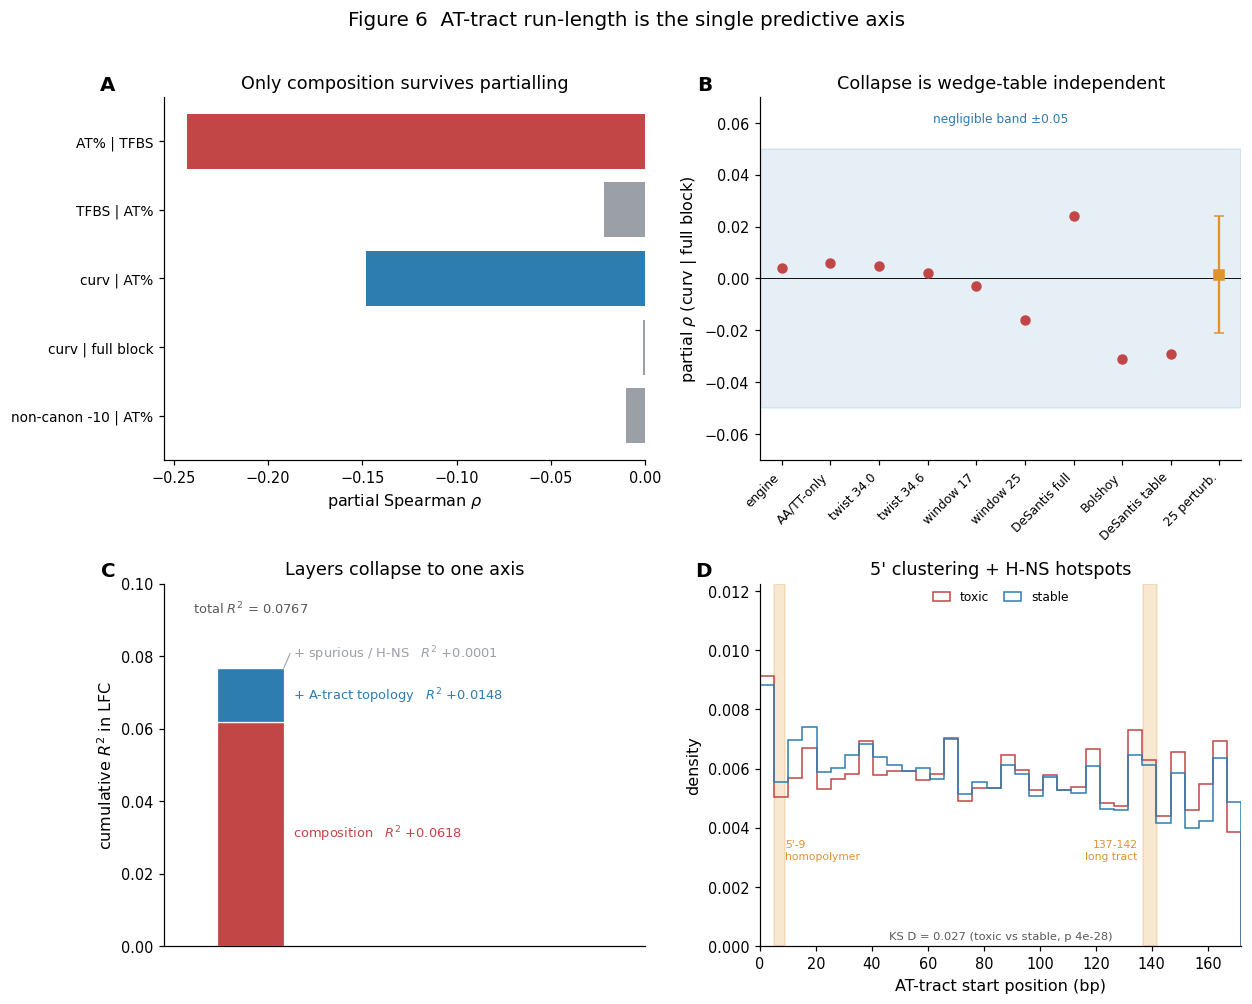

In [ ]:
#@title Figure 6 — single compositional axis
# ===== Figure 6 — single compositional axis =====
fig, ax = plt.subplots(2, 2, figsize=(11.5, 9))

# 6A partial-rho beyond composition
a = ax[0, 0]
items = [('AT% | TFBS', -0.243, COL['comp']), ('TFBS | AT%', -0.022, COL['alt']),
         ('curv | AT%', -0.148, COL['stable']), ('curv | full block', -0.001, COL['alt']),
         ('non-canon -10 | AT%', -0.010, COL['alt'])]
names = [i[0] for i in items]; vals = [i[1] for i in items]; cols = [i[2] for i in items]
a.barh(range(len(names)), vals, color=cols)
a.axvline(0, color='k', lw=0.6)
a.set_yticks(range(len(names))); a.set_yticklabels(names, fontsize=9)
a.invert_yaxis(); a.set_xlabel(r'partial Spearman $\rho$')
a.set_title('Only composition survives partialling'); panel_letter(a, 'A')

# 6B curvature robustness across 34 configs
b = ax[0, 1]
cfg = [('engine', 0.004), ('AA/TT-only', 0.006), ('twist 34.0', 0.005),
       ('twist 34.6', 0.002), ('window 17', -0.003), ('window 25', -0.016),
       ('DeSantis full', 0.024), ('Bolshoy', -0.031), ('DeSantis table', -0.029)]
b.axhspan(-0.05, 0.05, color=COL['stable'], alpha=0.12)
b.axhline(0, color='k', lw=0.6)
b.scatter(range(len(cfg)), [c[1] for c in cfg], color=COL['comp'], zorder=3, s=34)
b.errorbar(len(cfg), 0.0015, yerr=[[0.0015+0.021], [0.024-0.0015]], fmt='s',
           color=COL['hi'], capsize=3)
labs = [c[0] for c in cfg] + ['25 perturb.']
b.set_xticks(range(len(cfg)+1)); b.set_xticklabels(labs, rotation=45, ha='right', fontsize=8)
b.set_ylim(-0.07, 0.07); b.set_ylabel(r'partial $\rho$ (curv | full block)')
b.text(0.5, 0.93, 'negligible band ±0.05', transform=b.transAxes, ha='center',
       fontsize=8, color=COL['stable'])
b.set_title('Collapse is wedge-table independent'); panel_letter(b, 'B')

# 6C nested-layer: single stacked bar with labeled sections
c = ax[1, 0]
seg = [('composition', 0.0618, COL['comp']),
       ('+ A-tract topology', 0.0148, COL['stable']),
       ('+ spurious / H-NS', 0.0001, COL['alt'])]
xb, bw, bottom = 0.0, 0.42, 0.0
mids = []
for name, h, col in seg:
    c.bar(xb, h, bottom=bottom, width=bw, color=col, edgecolor='white', linewidth=0.8)
    mids.append((name, bottom + h/2, h, col)); bottom += h
xr = xb + bw/2 + 0.06
for name, ymid, h, col in mids:
    lab = f'{name}   $R^2$ +{h:.4f}'
    if h < 0.003:                              # tiny top segment: leader + offset label
        ytext = bottom + 0.004
        c.plot([xb + bw/2, xr - 0.02], [ymid, ytext], color=col, lw=0.7)
        c.text(xr, ytext, lab, va='center', fontsize=8.5, color=col)
    else:
        c.text(xr, ymid, lab, va='center', fontsize=8.5, color=col)
c.text(xb, bottom + 0.015, f'total $R^2$ = {bottom:.4f}', ha='center',
       fontsize=8.5, color=COL['ceil'])
c.set_xlim(-0.55, 2.5); c.set_ylim(0, 0.10); c.set_xticks([])
c.set_ylabel(r'cumulative $R^2$ in LFC')
c.set_title('Layers collapse to one axis'); panel_letter(c, 'C')

# 6D positional clustering with Cell 28c hotspots (loads globals; placeholder fallback)
d = ax[1, 1]
g = load_globals()
try:
    ts = np.asarray(g['toxic_at_starts'], float); ss = np.asarray(g['stable_at_starts'], float)
    ts = ts[np.isfinite(ts)]; ss = ss[np.isfinite(ss)]
    bins = np.linspace(0, 172, 35)
    d.hist(ts, bins=bins, density=True, histtype='step', color=COL['comp'], lw=1.6, label='toxic')
    d.hist(ss, bins=bins, density=True, histtype='step', color=COL['stable'], lw=1.6, label='stable')
    d.set_ylim(top=d.get_ylim()[1] * 1.28)          # headroom so the legend clears the lines
    d.legend(frameon=False, loc='upper center', ncol=2, fontsize=8,
             handlelength=1.4, columnspacing=1.2, borderaxespad=0.2)
    d.set_ylabel('density')
except Exception:
    d.text(0.5, 0.62, 'load toxic_at_starts / stable_at_starts\n(savepoint globals)',
           ha='center', va='center', transform=d.transAxes, color=COL['alt'])
    d.set_yticks([])
for lo, hi in [(5, 9), (137, 142)]:
    d.axvspan(lo, hi, color=COL['hi'], alpha=0.22)
ytop = d.get_ylim()[1]
d.text(9, ytop * 0.24, "5'-9\nhomopolymer", ha='left', fontsize=7, color=COL['hi'])
d.text(135, ytop * 0.24, "137-142\nlong tract", ha='right', fontsize=7, color=COL['hi'])
d.text(0.5, 0.02, 'KS D = 0.027 (toxic vs stable, p 4e-28)', transform=d.transAxes,
       ha='center', fontsize=7.5, color=COL['ceil'])
d.set_xlim(0, 172); d.set_xlabel('AT-tract start position (bp)')
d.set_title("5' clustering + H-NS hotspots"); panel_letter(d, 'D')

fig.suptitle('Figure 6  AT-tract run-length is the single predictive axis', y=1.01, fontsize=13)
fig.tight_layout()
save_fig(fig, 'Fig6_single_axis')

saved /content/drive/MyDrive/Plasmids/figures/Fig7_host_and_transfer.png


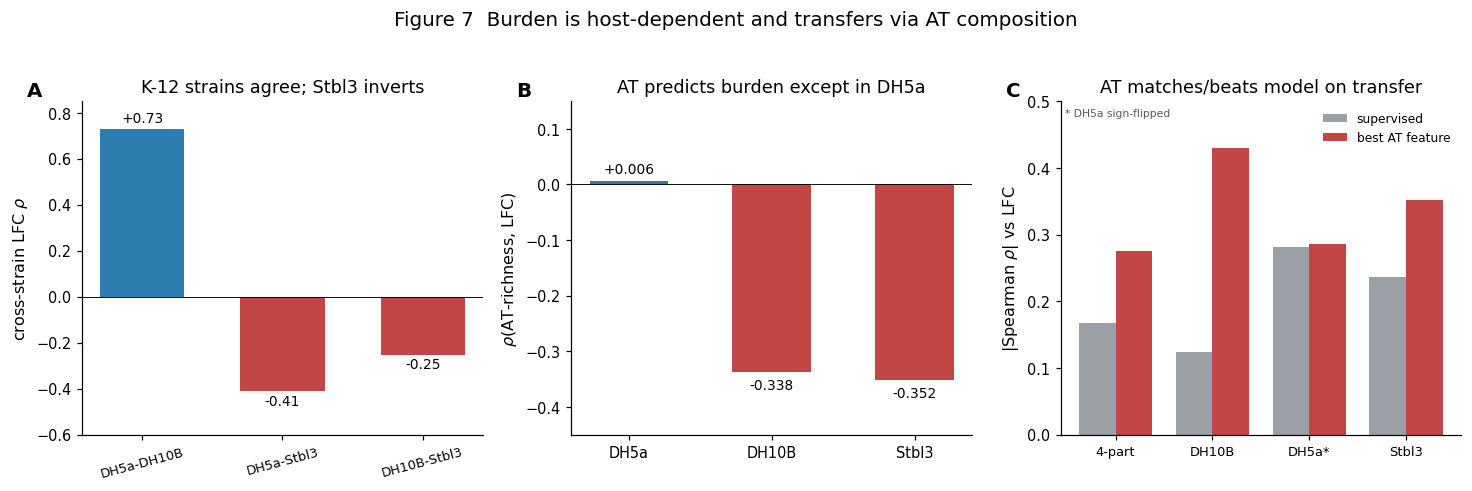

In [ ]:
#@title Figure 7 — host dependence and length transfer
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.3))

# 7A cross-strain pairwise
a = ax[0]
pairs = ['DH5a-DH10B', 'DH5a-Stbl3', 'DH10B-Stbl3']
vals = [0.727, -0.411, -0.253]
a.bar(pairs, vals, color=[COL['stable'] if v > 0 else COL['comp'] for v in vals], width=0.6)
a.axhline(0, color='k', lw=0.6); a.set_ylabel(r'cross-strain LFC $\rho$'); a.set_ylim(-0.6, 0.85)
for i, v in enumerate(vals):
    a.text(i, v + (0.03 if v > 0 else -0.06), f'{v:+.2f}', ha='center', fontsize=9)
a.set_xticklabels(pairs, rotation=15, fontsize=8.5)
a.set_title('K-12 strains agree; Stbl3 inverts'); panel_letter(a, 'A')

# 7B DH5a AT inversion
b = ax[1]
strains = ['DH5a', 'DH10B', 'Stbl3']
rho_at = [0.006, -0.338, -0.352]
b.bar(strains, rho_at, color=[COL['stable'] if v >= 0 else COL['comp'] for v in rho_at], width=0.55)
b.axhline(0, color='k', lw=0.6); b.set_ylabel(r'$\rho$(AT-richness, LFC)'); b.set_ylim(-0.45, 0.15)
for i, v in enumerate(rho_at):
    b.text(i, v + (0.015 if v >= 0 else -0.03), f'{v:+.3f}', ha='center', fontsize=9)
b.set_title('AT predicts burden except in DH5a'); panel_letter(b, 'B')

# 7C cross-length transfer: supervised vs best AT feature (|rho|)
c = ax[2]
tiers = ['4-part', 'DH10B', 'DH5a*', 'Stbl3']
sup = [0.167, 0.124, 0.282, 0.237]
at_ = [0.276, 0.429, 0.286, 0.352]
x = np.arange(len(tiers)); w = 0.38
c.bar(x - w/2, sup, w, label='supervised', color=COL['alt'])
c.bar(x + w/2, at_, w, label='best AT feature', color=COL['comp'])
c.set_xticks(x); c.set_xticklabels(tiers, fontsize=8.5)
c.set_ylabel(r'|Spearman $\rho$| vs LFC'); c.set_ylim(0, 0.5)
c.legend(frameon=False, fontsize=8, loc='upper right')
c.text(0.01, 0.98, '* DH5a sign-flipped', transform=c.transAxes, ha='left', va='top', fontsize=7, color=COL['ceil'])
c.set_title('AT matches/beats model on transfer'); panel_letter(c, 'C')

fig.suptitle('Figure 7  Burden is host-dependent and transfers via AT composition', y=1.03, fontsize=13)
fig.tight_layout()
save_fig(fig, 'Fig7_host_and_transfer')

saved /content/drive/MyDrive/Plasmids/figures/Fig8_feature_attribution.png


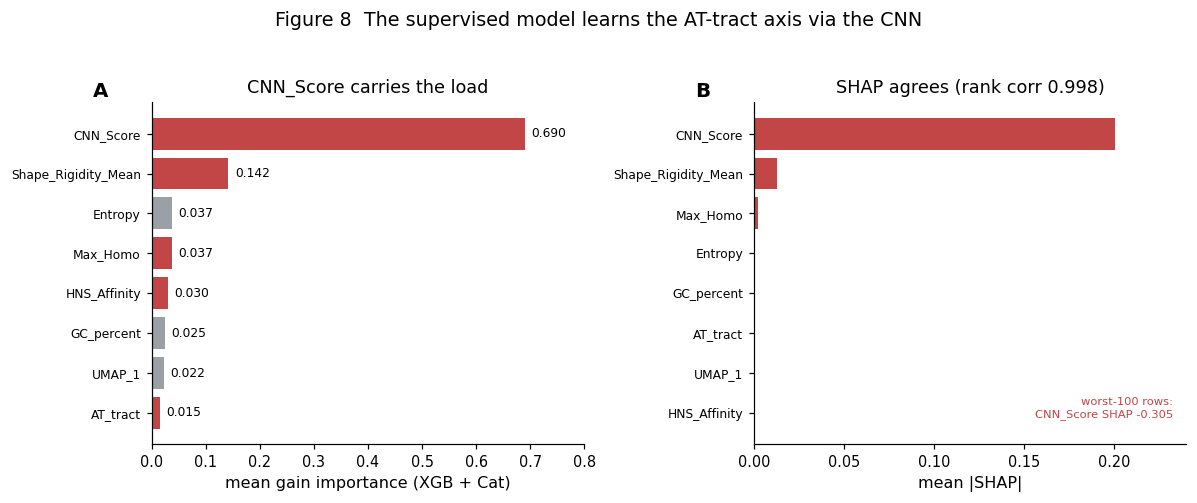

In [ ]:
#@title Figure 8 — supervised feature attribution
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
EMPH = {'CNN_Score', 'Shape_Rigidity_Mean', 'Max_Homo', 'AT_tract', 'HNS_Affinity'}

# 8A gain importance (Cell 23d)
a = ax[0]
imp = [('CNN_Score', 0.690), ('Shape_Rigidity_Mean', 0.142), ('Entropy', 0.0375),
       ('Max_Homo', 0.0373), ('HNS_Affinity', 0.0305), ('GC_percent', 0.0247),
       ('UMAP_1', 0.0223), ('AT_tract', 0.0151)]
imp = sorted(imp, key=lambda x: x[1])
names = [i[0] for i in imp]; vals = [i[1] for i in imp]
a.barh(range(len(names)), vals, color=[COL['comp'] if n in EMPH else COL['alt'] for n in names])
for i, v in enumerate(vals):
    a.text(v + 0.012, i, f'{v:.3f}', va='center', fontsize=8)
a.set_yticks(range(len(names))); a.set_yticklabels(names, fontsize=8)
a.set_xlim(0, 0.80); a.set_xlabel('mean gain importance (XGB + Cat)')
a.set_title('CNN_Score carries the load'); panel_letter(a, 'A')

# 8B SHAP (Cell 23m)
b = ax[1]
sh = [('CNN_Score', 0.2004), ('Shape_Rigidity_Mean', 0.0127), ('Max_Homo', 0.0025),
      ('Entropy', 0.0004), ('GC_percent', 0.0002), ('HNS_Affinity', 0.0001),
      ('UMAP_1', 0.0001), ('AT_tract', 0.0001)]
sh = sorted(sh, key=lambda x: x[1])
names = [s[0] for s in sh]; vals = [s[1] for s in sh]
b.barh(range(len(names)), vals, color=[COL['comp'] if n in EMPH else COL['alt'] for n in names])
b.set_yticks(range(len(names))); b.set_yticklabels(names, fontsize=8)
b.set_xlim(0, 0.24); b.set_xlabel('mean |SHAP|')
b.text(0.97, 0.08, 'worst-100 rows:\nCNN_Score SHAP -0.305', transform=b.transAxes,
       ha='right', fontsize=7.5, color=COL['comp'])
b.set_title('SHAP agrees (rank corr 0.998)'); panel_letter(b, 'B')

fig.suptitle('Figure 8  The supervised model learns the AT-tract axis via the CNN', y=1.03, fontsize=12.5)
fig.tight_layout()
save_fig(fig, 'Fig8_feature_attribution')


In [ ]:
print('All figures written to', OUTDIR)


All figures written to /content/drive/MyDrive/Plasmids/figures
